# 01. LangChain V1 개요

> LangChain V1은 체인(LCEL) 중심에서 **에이전트 우선**으로 무게 중심을 옮긴 메이저 업데이트예요. 패키지 재구조화, `init_chat_model`, Content Blocks, V0 → V1 마이그레이션 포인트를 한 번에 정리해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. LangChain V0에서 V1으로의 철학적 전환(체인 기반 → 에이전트 우선)을 설명할 수 있어요
2. V1 패키지 재구조화 내용을 파악하고 올바른 import 경로를 사용할 수 있어요
3. `init_chat_model("provider:model")` 통합 패턴으로 다양한 모델을 초기화할 수 있어요
4. Content Blocks 개념을 이해하고 멀티모달 메시지를 구성할 수 있어요
5. V0에서 V1으로 마이그레이션 시 주요 Breaking Change를 식별할 수 있어요

## 사전 지식

- LangChain V0 기본 사용 경험 (체인, 모델, 프롬프트)
- Python 3.10+ 환경 준비
- OpenAI API 키 보유


## LangChain V1이란?

LangChain V1은 2025년 출시된 메이저 버전으로, LLM 생태계의 변화를 반영한 **근본적인 철학 전환**을 담고 있어요.

### V0 → V1 타임라인

| 버전 | 출시 | 핵심 특징 |
|------|------|----------|
| v0.0.1 | 2022년 | LLM 체인, 에이전트 초기 형태 |
| v0.1.0 | 2024년 | 안정화, `langchain-core` 분리 |
| v1.0.0 | 2025년 | 에이전트 우선, 패키지 재구조화 |

### 철학의 전환: 체인 기반 → 에이전트 우선

V0는 **LCEL(LangChain Expression Language)** 체인을 중심으로 설계되었어요. `pipe(|)` 연산자로 컴포넌트를 연결하는 방식이죠.

V1은 **에이전트가 1등 시민(first-class citizen)** 으로 바뀌었어요. 모델이 도구를 선택하고, 추론하며, 반복적으로 실행하는 에이전트 패턴을 기본으로 합니다.

비유하자면, V0는 **조립 설명서**와 비슷해요. 순서대로 부품을 연결하면 완성품이 나와요. V1은 **숙련된 요리사**에 가까워요. 냉장고에 있는 재료(도구)를 보고, 상황에 맞게 레시피(추론)를 결정하고, 직접 요리(실행)해요.


## 전체 아키텍처

LangChain V1 생태계는 세 가지 레이어로 구성되어 있어요:

```mermaid
flowchart TD
    A["개발자 코드<br>(Your Code)"] --> B
    
    subgraph B["LangChain V1 패키지"]
        B1["langchain<br>(메인 SDK)"]
        B2["langchain-community<br>(서드파티 통합)"]
        B3["langchain-openai<br>(OpenAI 통합)"]
        B4["langchain-anthropic<br>(Anthropic 통합)"]
        B5["langchain-classic<br>(V0 호환 레이어)"]
    end
    
    subgraph C["런타임 & 하네스"]
        C1["LangGraph<br>(그래프 런타임)"]
        C2["Deep Agents<br>(에이전트 하네스)"]
    end
    
    B --> C
    C --> D["LLM 공급자<br>(OpenAI, Anthropic, Google...)"] 

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    
    class A input
    class B1,B2,B3,B4,B5 process
    class C1,C2 output
    class D storage
```

### V1 패키지 구조

V1에서는 `langchain` 패키지가 5개의 핵심 모듈로 정리되었어요:

| 모듈 | 용도 | 주요 import |
|------|------|-------------|
| `langchain.agents` | 에이전트 생성, 실행 | `create_agent` |
| `langchain.messages` | 메시지 타입 | `HumanMessage`, `AIMessage`, `SystemMessage`, `ToolMessage` |
| `langchain.chat_models` | 모델 초기화 | `init_chat_model` |
| `langchain.tools` | 도구 정의 | `tool` 데코레이터 |
| `langchain.retrievers` | 검색/RAG | `BaseRetriever` |

V0에서 `langchain_core`, `langchain_openai` 등에 분산되어 있던 import가 `langchain`으로 통합되었어요. 기존 코드 호환을 위한 `langchain-classic` 패키지도 제공해요.


## 1. 환경 설정


In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 읽어와요
from dotenv import load_dotenv

load_dotenv()


True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택사항)
# ---------------------------------------------------
# LangSmith로 실행 이력을 추적하고 싶을 때 설정해요
# .env에 LANGCHAIN_API_KEY가 있으면 자동으로 활성화됩니다
import os

# 추적을 활성화하려면 아래 주석을 해제하세요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Overview"

# 환경 설정 완료


## 2. V1 모델 초기화: `init_chat_model`

V1의 가장 큰 변화 중 하나는 `init_chat_model("provider:model")` 통합 패턴이에요.

V0에서는 각 공급자마다 다른 클래스를 사용해야 했어요:
```python
# V0 방식 (더 이상 권장하지 않아요)
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

openai_model = ChatOpenAI(model="gpt-4o-mini")
anthropic_model = ChatAnthropic(model="claude-sonnet-4-5")
```

V1에서는 하나의 함수로 모든 공급자를 통일해요:


In [3]:
# ---------------------------------------------------
# V1 모델 초기화
# ---------------------------------------------------
# init_chat_model: 모든 공급자를 통일된 인터페이스로 초기화해요
from langchain.chat_models import init_chat_model

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성 우선)
# 다른 모델로 교체하려면 문자열만 바꾸면 돼요:
#   Anthropic:  "anthropic:claude-sonnet-4-5"
#   Google:     "google_genai:gemini-2.0-flash"
model = init_chat_model("openai:gpt-4o-mini")

print(f"모델 타입: {type(model).__name__}")
print(f"모델 이름: {model.model_name}")


모델 타입: ChatOpenAI
모델 이름: gpt-4o-mini


In [5]:
from langchain.messages import HumanMessage, SystemMessage

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 기본 메시지 호출 테스트
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.

messages = [
    SystemMessage(content="당신은 친절한 AI 어시스턴트예요."),
    HumanMessage(content="LangChain V1의 가장 큰 특징을 한 문장으로 말해주세요."),
]

res = model.invoke(messages)

In [6]:
res

AIMessage(content='LangChain V1의 가장 큰 특징은 다양한 언어 모델과 데이터 소스를 통합하여 복잡한 애플리케이션을 쉽게 구축할 수 있는 프레임워크를 제공한다는 것입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 42, 'total_tokens': 86, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bf8989a65a', 'id': 'chatcmpl-DchTfjeHqLXTudwBssA29Icb6Ctqm', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dfff8-635f-7f32-b44c-3956ab4736af-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 44, 'total_tokens': 86, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## 3. Content Blocks: 멀티모달 표준화

### 왜 Content Blocks가 필요할까요?

V0에서는 OpenAI의 응답은 단순 문자열, Anthropic의 응답은 블록 리스트로 **공급자마다 응답 형식이 달랐어요**. 공급자를 바꿀 때마다 응답 파싱 코드도 바꿔야 했죠. Content Blocks는 이 문제를 해결하기 위해 **모든 공급자의 응답을 하나의 표준 형식**으로 통일해요.

V1의 핵심 신기능 중 하나는 **Content Blocks(컨텐츠 블록)** 이에요.

V0에서는 텍스트 응답이 단순 문자열로 반환되었어요:
```python
# V0: AIMessage.content = "텍스트 응답"
print(response.content)  # 문자열
```

V1에서는 텍스트, 이미지, 도구 호출 등이 모두 **Content Block 리스트**로 통일되어 있어요:

```mermaid
flowchart LR
    A["AIMessage"] --> B["content<br>(리스트)"] 
    B --> C1["TextBlock<br>{'type': 'text', 'text': '...'}"] 
    B --> C2["ToolUseBlock<br>{'type': 'tool_use', 'name': '...'}"] 
    B --> C3["ImageBlock<br>{'type': 'image', 'source': '...'}"] 
    
    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    
    class A input
    class B process
    class C1,C2,C3 output
```


In [8]:
from langchain.messages import HumanMessage

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: Content Blocks 구조 확인
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.
response = model.invoke([
    HumanMessage(content="안녕하세요")
])

response

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f266aff3a9', 'id': 'chatcmpl-DchfmozzJ3ZhTV4n4AGqBFvyH3TYK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e0003-d99b-7960-96d5-25073610b79e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [9]:
# V1에서 텍스트 추출하는 방법
# content가 문자열이면 그대로 사용
# content가 리스트(Content Blocks)면 text 타입 블록을 찾아요
if isinstance(response.content, str):
    text = response.content
elif isinstance(response.content, list):
    # Content Blocks 리스트에서 텍스트 추출
    text = " ".join(
        block["text"]
        for block in response.content
        if isinstance(block, dict) and block.get("type") == "text"
    )
else:
    text = str(response.content)

print(f"추출된 텍스트: {text}")

추출된 텍스트: 안녕하세요! 어떻게 도와드릴까요?


In [ ]:
from langchain.messages import HumanMessage

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: HumanMessage에 Content Blocks 사용하기
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 4. `create_agent`: 에이전트 생성 표준화

V0에서는 `create_react_agent`(LangGraph)를 사용했어요. V1에서는 `langchain.agents`의 `create_agent`가 표준이에요.

### V0 vs V1 에이전트 생성 비교

| 항목 | V0 | V1 |
|------|----|----|  
| import | `from langgraph.prebuilt import create_react_agent` | `from langchain.agents import create_agent` |
| 패턴 | ReAct 고정 | 다양한 패턴 지원 |
| 시스템 프롬프트 | `state_modifier` 파라미터 | `system_prompt` 파라미터 |
| 모델 초기화 | `ChatOpenAI()` 직접 | `init_chat_model()` 권장 |


In [11]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool

agent_model = init_chat_model("openai:gpt-4o-mini")

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: create_agent 기본 예제
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.

@tool
def get_weather(city: str) -> str:
    """
    이 함수는 특정 도시의 날씨를 조회하는 함수입니다.

    Args:
        city: 날씨를 알고 싶은 도시명
    """
    return f"{city}의 날씨는 맑습니다. 25도입니다."


@tool
def calculate(expression: str) -> str:
    """
    수학 표현식을 계산한다.

    Args:
        expression: 계산할 수식
    """
    try:
        result = eval(expression)
        return f"계산 결과 **{result}**"
    except Exception as e:
        return f"계산 오류 {e}"

agent_model = init_chat_model("openai:gpt-4o-mini")

tools = [get_weather, calculate]

agent = create_agent(
    model=agent_model,
    tools=tools,
    system_prompt="당신은 날씨 정보와 수학 계산을 도와주는 에이전트입니다."
)


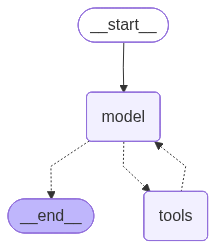

In [6]:
from IPython.display import Image, display

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → agent → tools → agent → ... → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.

display(Image(agent.get_graph().draw_mermaid_png()))


In [12]:
from langchain.messages import HumanMessage

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 에이전트 실행
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.

res = agent.invoke(
  {"messages": [HumanMessage(content="서울 날씨가 어때요? 그리고 15 곱하기 23은?")]}
)

last_message = res["messages"][-1]
print(last_message)


content='서울의 날씨는 맑고, 기온은 25도입니다. 그리고 15 곱하기 23은 345입니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 209, 'total_tokens': 240, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ec08ae704b', 'id': 'chatcmpl-Dci7WBFZxXmYrHlOlGVKhnIjH08kp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e001e-1cf6-70b2-bf1a-8721c2e25532-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 209, 'output_tokens': 31, 'total_tokens': 240, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


## 5. V0 → V1 마이그레이션 가이드

V0 코드를 V1으로 마이그레이션할 때 주의해야 할 **Breaking Changes**를 정리했어요.

### 주요 변경 사항

| 항목 | V0 | V1 | 영향 |
|------|----|----|------|
| 메시지 import | `from langchain_core.messages import ...` | `from langchain.messages import ...` | 낮음 |
| 모델 초기화 | `ChatOpenAI(model="...")` | `init_chat_model("openai:...")` | 중간 |
| 에이전트 생성 | `create_react_agent` (LangGraph) | `create_agent` (langchain) | 중간 |
| AIMessage 반환 타입 | `content: str` | `content: str \| list` | **높음** |
| 스트리밍 노드 이름 | `"agent"` | `"call_model"` (변경 가능) | 낮음 |
| `.text()` 메서드 | `response.text()` | `response.text` (속성) | **높음** |
| Python 최소 버전 | 3.8+ | **3.10+** | **높음** |


In [ ]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model = init_chat_model("openai:gpt-4o-mini")

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: Breaking Change 확인: AIMessage 반환 타입
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [ ]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

model = init_chat_model("openai:gpt-4o-mini")

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 스트리밍 응답
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 6. V1 Python 버전 요구사항과 현대적 타입 힌트

LangChain V1은 **Python 3.10+** 을 요구해요. 이는 단순한 요구사항 변경이 아니라, V1이 현대 Python 기능을 적극적으로 활용하기 때문이에요.

### Python 3.10+ 주요 기능 활용

| 기능 | 예시 | LangChain V1에서의 활용 |
|------|------|------------------------|
| `match-case` | `match msg_type: case "human":` | 메시지 타입 처리 |
| Union 타입 힌트 | `str \| list` | Content Blocks 타입 |
| `TypeAlias` | `MessageLike = str \| BaseMessage` | SDK 타입 정의 |
| Structural Pattern Matching | 복잡한 메시지 파싱 | 내부 구현 |


In [ ]:
import sys
import langchain
from importlib.metadata import version as pkg_version

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: Python 버전 및 LangChain 버전 확인
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [ ]:
from langchain.messages import AIMessage, HumanMessage
from langchain_core.messages import BaseMessage  # BaseMessage는 langchain_core에서 가져와요

model = init_chat_model("openai:gpt-4o-mini")

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: Python 3.10+ 타입 힌트 사용 예시
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 7. 실습: V0 코드를 V1으로 마이그레이션하기

지금까지 V1의 핵심 변경점을 살펴봤어요. 이제 **직접 손으로 바꿔보면서** 근육 기억을 만들 차례예요. 실무에서 V0 프로젝트를 V1으로 옮기는 작업은 한 번에 끝나지 않아요. 아래 실습으로 가장 자주 마주치는 3가지 변환 패턴을 연습해봐요.

아래 V0 스타일 코드를 V1 방식으로 변환해보세요.


In [ ]:
# ============================================================
# TODO: 아래 V0 스타일 코드를 V1 방식으로 변환해보세요
# 
# 변환해야 할 항목:
#   1. ChatOpenAI 직접 초기화 → init_chat_model 사용
#   2. langchain_core.messages → langchain.messages
#   3. response.content 처리 (str 가정 → 안전하게 처리)
#
# 힌트:
#   - init_chat_model("openai:gpt-4o-mini")
#   - from langchain.messages import HumanMessage
#   - match response.content: case str(): ... case list(): ...
#
# 예상 결과: 동일한 질문-응답이 작동하되 V1 API를 사용해야 해요
# ============================================================

# V0 스타일 코드 (참고용 - 수정하지 마세요)
# from langchain_openai import ChatOpenAI
# from langchain_core.messages import HumanMessage
#
# old_model = ChatOpenAI(model="gpt-4o-mini")
# old_response = old_model.invoke([HumanMessage(content="Python의 특징은?")])
# print(old_response.content)  # str로 가정

# 여기에 V1 방식으로 작성해보세요!
# 1. V1 import
# from langchain.chat_models import ...
# from langchain.messages import ...

# 2. V1 모델 초기화
# new_model = ...

# 3. 메시지 생성 및 호출
# new_response = ...

# 4. 안전한 텍스트 추출 (str | list 모두 처리)
# ...

# TODO를 완성해보세요!


In [ ]:
# TODO: 수업 시간에 함께 풀이 코드를 작성하세요.
# 이 셀은 학생용 교재에서 해답 코드를 의도적으로 비워 둡니다.


## 8. V1 빠른 요약 데모

지금까지 배운 V1 핵심 패턴을 종합해서 실용적인 예제를 만들어봐요.


In [ ]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langchain.tools import tool
import datetime

demo_model = init_chat_model("openai:gpt-4o-mini")  # 통합 초기화

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: V1 핵심 패턴 종합 예제
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


In [ ]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → agent → tools → agent → ... → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **V0 → V1 철학 전환**: "체인으로 묶는다" → "에이전트가 스스로 판단한다"로 패러다임이 바뀌었어요
- **패키지 재구조화**: `langchain_core`, `langchain_openai` 등으로 분산되었던 import가 `langchain.*`으로 통합되었어요
- **`init_chat_model`**: `"provider:model"` 형식으로 모든 공급자를 통일된 방식으로 초기화해요
- **Content Blocks**: 텍스트, 이미지, 도구 호출이 표준 블록 형식으로 통일되었어요; `content: str | list` 타입에 주의하세요
- **`create_agent`**: `create_react_agent`를 대체하는 V1 표준 에이전트 생성 함수예요
- **Breaking Changes**: `.text()` → `.text`, `str | list` content 타입, Python 3.10+ 요구사항에 주의하세요
- **Python 3.10+**: `match-case`, `str | list` 타입 힌트 등 현대적 Python 기능을 적극 활용해요


## 다음 노트북 예고

다음 `02-Product-Hierarchy.ipynb`에서는 **LangChain(Framework) vs LangGraph(Runtime) vs Deep Agents(Harness)** 의 제품 계층을 배워요. 각각이 언제, 왜 필요한지, 어떻게 조합해서 사용하는지 이해하면 전체 에코시스템이 한눈에 보일 거예요.
